# Benchmark for new DQN

In [2]:
import json
import math
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy

# Assuming these are in your local directory or environment
from scoring_service.HumanityScorer import scorer
from rl_service_offline_buffer_training import offline_rl_agent # Using the updated Balanced DQN Agent

# --- Configuration ---
DATA_DIR = "data"
MODEL_SAVE_PATH = "models/5/offline_rl_model_1_200.pt"


In [3]:
# Simulation Hyperparameters
TARGET_HUMAN_COUNT = 85
TARGET_BOT_COUNT = 200
SIMULATION_STEP_SECONDS = 10  # How often the RL agent is called (matches frontend)
SESSION_CHUNK_SIZE = int(SIMULATION_STEP_SECONDS * 1000)  # In milliseconds

conf = {
    "human": {"predicted": {"human": 0, "bot": 0}},
    "bot": {"predicted": {"human": 0, "bot": 0}}
}

In [4]:
def update_human_bot_population(human_count=None, bot_count=None):
    global TARGET_HUMAN_COUNT, TARGET_BOT_COUNT, conf
    TARGET_HUMAN_COUNT = random.randint(80, 100) if human_count is None else human_count
    TARGET_BOT_COUNT = random.choice([0, 20, 50, 100, 200, 1000]) if bot_count is None else bot_count
    
    # Reset Confusion Matrix for the new episode
    for key in ["human", "bot"]:
        for pred in ["human", "bot"]:
            conf[key]["predicted"][pred] = 0

def get_humanity_score(mouse_movement):
    if not mouse_movement:
        return None
    formatted_movements = [[m['x'], m['y']] for m in mouse_movement]
    try:
        # Assuming scorer is the LSTM model
        prediction = scorer.predict(formatted_movements)
        return float(prediction)
    except Exception as e:
        return 0.5

def calculate_reward(user, threat_level):
    """
    Refined reward function for balancing Security vs. UX.
    Weights are normalized so that one 'Happy Human' is roughly 
    equivalent to one 'Caught Bot'.
    """
    reward = 0
    done = False
    
    # Constants for tuning
    MAX_REWARD = 50.0        # Baseline for a 'Perfect' action
    LEAKAGE_PENALTY = -150.0 # Bot got through (Critical Failure)
    FRICTION_BASE = 2.0      # Sensitivity to human annoyance
    
    if user.is_bot:
        if threat_level > user.bot_strength:
            # Bot CAUGHT
            overkill = (threat_level - user.bot_strength)
            reward = MAX_REWARD - (overkill * 2.5) # Penalty for using high level on weak bot
            done = True
            user.reset_session()
        else:
            # Bot SURVIVED / LEAKED
            gap = user.bot_strength - threat_level
            reward = LEAKAGE_PENALTY - (gap * 5.0)
            user.captchas_solved += 1
    else:
        # HUMAN logic
        if threat_level == 0:
            reward = MAX_REWARD # Perfect score for zero friction
        else:
            # Level 1 is annoying, Level 10 is session-ending frustration
            frustration = math.pow(FRICTION_BASE, threat_level)
            reward = (MAX_REWARD / 2.0) - frustration
            
        user.captchas_solved += 1
        
        # Check if human gave up (Simulated patience)
        if threat_level == 10 or random.random() * (threat_level - 6) > 0.5:
            done = True # Human abandoned site due to high friction

    return reward, done


def load_session_data(data_dir):
    """Loads all human and bot raw data files."""
    human_sessions = []
    bot_sessions = []
    print(f"Loading raw session data from {data_dir}...")
    for filename in os.listdir(data_dir):
        if not filename.endswith('.json'): continue
        filepath = os.path.join(data_dir, filename)
        try:
            with open(filepath, 'r') as f:
                data = json.load(f)
            if filename.startswith('human'):
                human_sessions.append(data)
            elif filename.startswith('bot'):
                bot_sessions.append(data)
        except Exception as e:
            print(f"Warning: Could not load or parse {filename}. Error: {e}")

    print(f"Loaded {len(human_sessions)} human sessions and {len(bot_sessions)} bot sessions.")
    if not human_sessions or not bot_sessions:
        print("Error: Not enough data to run simulation. Please run bot simulator and browse site.")
        exit()
    return human_sessions, bot_sessions


def perturb_mouse_data(movements):
    """Creates a 'new' user by slightly altering existing mouse data."""
    if not movements: return []
    # Add small random noise to each coordinate
    noise_x = random.randint(-5//5, 5//5)
    noise_y = random.randint(-5//5, 5//5)
    return [{**m, 'x': m['x'] + noise_x, 'y': m['y'] + noise_y, 'timestamp': m['timestamp']} for m in movements]


def get_session_chunks(session_data, chunk_size_ms, target_chunks_size=12):
    """Splits a full session's mouse data into 10-second (step) chunks."""
    start_time = session_data['timestamps']['start']
    movements = session_data.get('mouse_movements', [])
    if not movements: return [[]]  # Return one empty chunk

    chunks = []
    current_chunk = []
    chunk_end_time = start_time + chunk_size_ms

    for move in movements:
        if move['timestamp'] <= chunk_end_time:
            current_chunk.append(move)
        else:
            chunks.append(current_chunk)
            if len(chunks) == target_chunks_size:
                return chunks
            # Handle multiple empty steps
            while move['timestamp'] > chunk_end_time + chunk_size_ms:
                chunks.append([])
                if len(chunks) == target_chunks_size:
                    return chunks
                chunk_end_time += chunk_size_ms

            current_chunk = [move]
            chunk_end_time += chunk_size_ms

    chunks.append(current_chunk)  # Add the last chunk
    if len(chunks) < target_chunks_size:
        chunks = chunks + get_session_chunks(session_data, chunk_size_ms, target_chunks_size=target_chunks_size - len(chunks))
    return chunks


# --- Simulation Classes ---

class SimulatedUser:
    def __init__(self, base_session_data, is_bot):
        self.is_bot = is_bot
        self.client_id = f"{'bot' if is_bot else 'human'}_{random.randint(10000, 99999)}"
        self.captchas_solved = 0
        self.last_captcha_solved = 0
        self.done = False
        self.last_humanity_score = 0.5
        self.average_humanity_score = 0.5
        self.n_humanity_score = 0
        self.bot_strength = random.randint(0, 9) if is_bot else None

        # Perturb and chunk the data to create a new, unique session
        perturbed_movements = perturb_mouse_data(base_session_data.get('mouse_movements', []))
        perturbed_session = {**base_session_data, 'mouse_movements': perturbed_movements}
        self.session_chunks = get_session_chunks(perturbed_session, SESSION_CHUNK_SIZE)
        self.current_chunk_index = 0

    def get_step_data(self):
        if self.current_chunk_index >= len(self.session_chunks):
            self.done = True
            return None
        chunk = self.session_chunks[self.current_chunk_index]
        self.current_chunk_index += 1
        return chunk
    
    def update_stats(self, h_score):
        if h_score is not None:
            self.last_humanity_score = h_score
            self.average_humanity_score = (self.average_humanity_score * self.n_humanity_score + h_score) / (self.n_humanity_score + 1)
            self.n_humanity_score += 1

    def reset_session(self):
        self.captchas_solved = 0
        self.done = True

In [ ]:
# MODEL_SAVE_PATH = "models/5/offline_rl_model_1_200.pt"
MODEL_SAVE_PATH = "models/6/offline_rl_model_2_186.pt"
# MODEL_SAVE_PATH = "models/5/best_model_1_1.pt"

offline_rl_agent.load_model(MODEL_SAVE_PATH)

update_human_bot_population(human_count=100, bot_count=100)

Loading offline model from models/5/best_model_1_1.pt...
Offline model loaded successfully.


In [ ]:
# Track population over time
human_counts = []
bot_counts = []
timestep_counts = []
current_timestep = 0

# This dict holds the (s, a, r, done) tuple from step t-1, waiting for s' at step t
pending_experiences = {}
episode_reward = 0

print("--- Starting Offline Training Simulator ---")
base_human_sessions, base_bot_sessions = load_session_data(DATA_DIR)

# update_human_bot_population(human_count=85, bot_count=200)

# 1. Create the population for this episode
print(f"Creating population: {TARGET_HUMAN_COUNT} humans, {TARGET_BOT_COUNT} bots")
active_users = []
for _ in range(TARGET_HUMAN_COUNT):
    active_users.append(SimulatedUser(random.choice(base_human_sessions), is_bot=False))
for _ in range(TARGET_BOT_COUNT):
    active_users.append(SimulatedUser(random.choice(base_bot_sessions), is_bot=True))
    
random.shuffle(active_users)

human_count = TARGET_HUMAN_COUNT
bot_count = TARGET_BOT_COUNT

while active_users:
    # ---- Population tracking per timestep ----
    human_count = sum(1 for u in active_users if not u.is_bot)
    bot_count = sum(1 for u in active_users if u.is_bot)
    
    human_counts.append(human_count)
    bot_counts.append(bot_count)
    timestep_counts.append(current_timestep)
    current_timestep += 1
    
    server_total_users = len(active_users)
    server_req_rate_per_min = server_total_users * 7   # (random.randint(5, 15))

    next_active_users = []
    new_pending_experiences = {}

    for user in active_users:
        # 1. Get user's data and calculate current state s_t
        mouse_data = user.get_step_data()
        humanity_score = get_humanity_score(mouse_data)
        
        # if user.is_bot and humanity_score is not None:
        #     humanity_score = humanity_score ** 4
            # print(humanity_score)

        user.update_stats(humanity_score)

        if humanity_score is None:
            humanity_score = user.average_humanity_score

        conf["bot" if user.is_bot else "human"]["predicted"]["bot" if humanity_score >= .5 else "human"] += 1
        # print(user.is_bot, humanity_score)

        s_t = [
            humanity_score,
            user.average_humanity_score,
            user.captchas_solved,
            user.last_captcha_solved,   # client_req_rate_per_min, avg_h_score
            # server_req_rate_per_min,
            server_total_users
        ]

        # 2. Finalize the experience from step t-1
        if user.client_id in pending_experiences:
            prev_s, prev_a, prev_r, prev_done = pending_experiences[user.client_id]
            s_prime = s_t  # The current state is the "next_state" for the previous action

            # Store the *completed* transition from t-1
            # offline_rl_agent.remember(prev_s, prev_a, prev_r, s_prime, prev_done, user.is_bot)
            episode_reward += prev_r

        # 3. Check if user's session ended *naturally* (ran out of data)
        if user.done:
            continue  # User is done, no new action to take

        # 4. User is still active, take a new action (a_t)
        a_t = offline_rl_agent.select_action(s_t)
        
        # a_t = 10 if humanity_score > 0.5 else 0   
        # a_t = int(humanity_score * 10)

        # 5. Calculate reward (r_t) and if the action *caused* the session to end (done_t)
        r_t, done_t = calculate_reward(user, a_t)

        # print(f"{'Bottt' if user.is_bot else 'Human'} -> action: {a_t}, reward {r_t}, done: {done_t}, score: {humanity_score}")

        # 6. Store this new experience
        if done_t:
            # This is a terminal state (e.g., bot was killed).
            # We have the full experience now. Store it immediately.
            s_prime = s_t  # The 'next_state' is arbitrary, as 'done=True' nullifies it.
            # offline_rl_agent.remember(s_t, a_t, r_t, s_prime, True, user.is_bot)
            episode_reward += r_t
            
            # if user.is_bot:
            #     bot_count -= 1
            
        else:
            # This is a non-terminal state.
            # Store it as pending, waiting for s' from the next step.
            new_pending_experiences[user.client_id] = (s_t, a_t, r_t, done_t)
            user.last_captcha_solved = a_t
            next_active_users.append(user)  # User continues

    
    if not next_active_users:
        print(f"Final remaining humans: {sum(1 for u in active_users if not u.is_bot)}")
        print(f"Final remaining bots: {sum(1 for u in active_users if u.is_bot)}")

    # --- End of Step ---
    active_users = next_active_users
    pending_experiences = new_pending_experiences

    if not active_users:
        print(f"All users finished.")
        
print(f"Net reward: {episode_reward}")
print(f"Normalized reward: {episode_reward / (TARGET_BOT_COUNT + TARGET_HUMAN_COUNT):0.2f}")
print(f"Confusion Matrix: {conf}")

--- Starting Offline Training Simulator ---
Loading raw session data from data...
Loaded 32 human sessions and 41 bot sessions.
Creating population: 100 humans, 100 bots
Final remaining humans: 83
Final remaining bots: 15
All users finished.
Net reward: 5522.0
Normalized reward: 27.61
Confusion Matrix: {'human': {'predicted': {'human': 1968, 'bot': 265}}, 'bot': {'predicted': {'human': 310, 'bot': 219}}}


In [9]:
# MODEL_SAVE_PATH = "models/5/offline_rl_model_1_200.pt"
MODEL_SAVE_PATH = "models/6/best_model_2_0.pt"

offline_rl_agent.load_model(MODEL_SAVE_PATH)

Loading offline model from models/6/best_model_2_0.pt...
Offline model loaded successfully.


In [10]:
bot_counts_lst = [0, 20, 100, 200, 500, 1000]
h_count = 100

dct = dict()

for b_count in bot_counts_lst:
    update_human_bot_population(human_count=h_count, bot_count=b_count)

    # Track population over time
    human_counts = []
    bot_counts = []
    timestep_counts = []
    current_timestep = 0

    # This dict holds the (s, a, r, done) tuple from step t-1, waiting for s' at step t
    pending_experiences = {}
    episode_reward = 0
    global_step_counter = 0
    episode_h_step_counter = 0
    episode_b_step_counter = 0
    episode_human_reward = 0
    episode_bot_reward = 0

    print("--- Starting Offline Training Simulator ---")
    base_human_sessions, base_bot_sessions = load_session_data(DATA_DIR)

    # update_human_bot_population(human_count=85, bot_count=200)

    # 1. Create the population for this episode
    print(f"Creating population: {TARGET_HUMAN_COUNT} humans, {TARGET_BOT_COUNT} bots")
    active_users = []
    for _ in range(TARGET_HUMAN_COUNT):
        active_users.append(SimulatedUser(random.choice(base_human_sessions), is_bot=False))
    for _ in range(TARGET_BOT_COUNT):
        active_users.append(SimulatedUser(random.choice(base_bot_sessions), is_bot=True))
        
    random.shuffle(active_users)

    human_count = TARGET_HUMAN_COUNT
    bot_count = TARGET_BOT_COUNT

    while active_users:
        # ---- Population tracking per timestep ----
        human_count = sum(1 for u in active_users if not u.is_bot)
        bot_count = sum(1 for u in active_users if u.is_bot)
        
        human_counts.append(human_count)
        bot_counts.append(bot_count)
        timestep_counts.append(current_timestep)
        current_timestep += 1
        
        server_total_users = len(active_users)
        server_req_rate_per_min = server_total_users * 7   # (random.randint(5, 15))

        next_active_users = []
        new_pending_experiences = {}

        for user in active_users:
            # 1. Get user's data and calculate current state s_t
            mouse_data = user.get_step_data()
            humanity_score = get_humanity_score(mouse_data)
            
            # if user.is_bot and humanity_score is not None:
            #     humanity_score = humanity_score ** 4
                # print(humanity_score)

            user.update_stats(humanity_score)

            if humanity_score is None:
                humanity_score = user.average_humanity_score

            conf["bot" if user.is_bot else "human"]["predicted"]["bot" if humanity_score >= .5 else "human"] += 1
            # print(user.is_bot, humanity_score)

            s_t = [
                humanity_score,
                user.average_humanity_score,
                user.captchas_solved,
                user.last_captcha_solved,   # client_req_rate_per_min, avg_h_score
                # server_req_rate_per_min,
                server_total_users
            ]

            # 2. Finalize the experience from step t-1
            if user.client_id in pending_experiences:
                prev_s, prev_a, prev_r, prev_done = pending_experiences[user.client_id]
                s_prime = s_t  # The current state is the "next_state" for the previous action

                # Store the *completed* transition from t-1
                # offline_rl_agent.remember(prev_s, prev_a, prev_r, s_prime, prev_done, user.is_bot)
                episode_reward += prev_r

            # 3. Check if user's session ended *naturally* (ran out of data)
            if user.done:
                continue  # User is done, no new action to take

            # 4. User is still active, take a new action (a_t)
            a_t = offline_rl_agent.select_action(s_t)
            
            # a_t = 10 if humanity_score > 0.5 else 0   
            # a_t = int(humanity_score * 10)

            # 5. Calculate reward (r_t) and if the action *caused* the session to end (done_t)
            r_t, done_t = calculate_reward(user, a_t)

            if user.is_bot:
                episode_bot_reward += r_t
                episode_b_step_counter += 1
            else:
                episode_human_reward += r_t
                episode_h_step_counter += 1
                
            global_step_counter += 1

            # print(f"{'Bottt' if user.is_bot else 'Human'} -> action: {a_t}, reward {r_t}, done: {done_t}, score: {humanity_score}")

            # 6. Store this new experience
            if done_t:
                # This is a terminal state (e.g., bot was killed).
                # We have the full experience now. Store it immediately.
                s_prime = s_t  # The 'next_state' is arbitrary, as 'done=True' nullifies it.
                # offline_rl_agent.remember(s_t, a_t, r_t, s_prime, True, user.is_bot)
                episode_reward += r_t
                
                # if user.is_bot:
                #     bot_count -= 1
                
            else:
                # This is a non-terminal state.
                # Store it as pending, waiting for s' from the next step.
                new_pending_experiences[user.client_id] = (s_t, a_t, r_t, done_t)
                user.last_captcha_solved = a_t
                next_active_users.append(user)  # User continues

        
        if not next_active_users:
            print(f"Final remaining humans: {sum(1 for u in active_users if not u.is_bot)}")
            print(f"Final remaining bots: {sum(1 for u in active_users if u.is_bot)}")

        # --- End of Step ---
        active_users = next_active_users
        pending_experiences = new_pending_experiences

        if not active_users:
            print(f"All users finished.")

    # Metrics logging...
    avg_rew = episode_reward / (episode_h_step_counter + episode_b_step_counter)   # (TARGET_HUMAN_COUNT + TARGET_BOT_COUNT)
    avg_human_rew = episode_human_reward / episode_h_step_counter
    avg_bot_rew = episode_bot_reward / episode_b_step_counter if episode_b_step_counter else 0
    print(f"Total Reward: {episode_reward:.2f} | Avg: {avg_rew:.2f} | Avg Human: {avg_human_rew:.2f} | Avg Bot: {avg_bot_rew:.2f}")
        
    avg_session_rew = episode_reward / (TARGET_HUMAN_COUNT + TARGET_BOT_COUNT)
    avg_h_session_rew = episode_human_reward / (TARGET_HUMAN_COUNT)
    avg_b_session_rew = episode_bot_reward / TARGET_BOT_COUNT if TARGET_BOT_COUNT else 0
    print(f"Average Session Rewards::: Mean: {avg_session_rew:.2f} | Human: {avg_h_session_rew:.2f} | Bot: {avg_b_session_rew:.2f}")

            
    print(f"Net reward: {episode_reward}")
    print(f"Normalized reward: {episode_reward / (TARGET_BOT_COUNT + TARGET_HUMAN_COUNT):0.2f}")
    print("Confusion Matrix:\n", conf)
    print("\n\n")

    dct[b_count] = {
        "timesteps": timestep_counts,
        "human_counts": human_counts,
        "bot_counts": bot_counts
    }

# with open("eval_dqn.json", "w") as f:
#     json.dump(dct, f)

--- Starting Offline Training Simulator ---
Loading raw session data from data...
Loaded 32 human sessions and 41 bot sessions.
Creating population: 100 humans, 0 bots
Final remaining humans: 68
Final remaining bots: 0
All users finished.
Total Reward: 15014.00 | Avg: 16.11 | Avg Human: 16.11 | Avg Bot: 0.00
Average Session Rewards::: Mean: 150.14 | Human: 150.14 | Bot: 0.00
Net reward: 15014.0
Normalized reward: 150.14
Confusion Matrix:
 {'human': {'predicted': {'human': 876, 'bot': 124}}, 'bot': {'predicted': {'human': 0, 'bot': 0}}}



--- Starting Offline Training Simulator ---
Loading raw session data from data...
Loaded 32 human sessions and 41 bot sessions.
Creating population: 100 humans, 20 bots
Final remaining humans: 64
Final remaining bots: 0
All users finished.
Total Reward: 18952.00 | Avg: 19.89 | Avg Human: 20.48 | Avg Bot: -2.00
Average Session Rewards::: Mean: 157.93 | Human: 190.02 | Bot: -2.50
Net reward: 18952.0
Normalized reward: 157.93
Confusion Matrix:
 {'human':

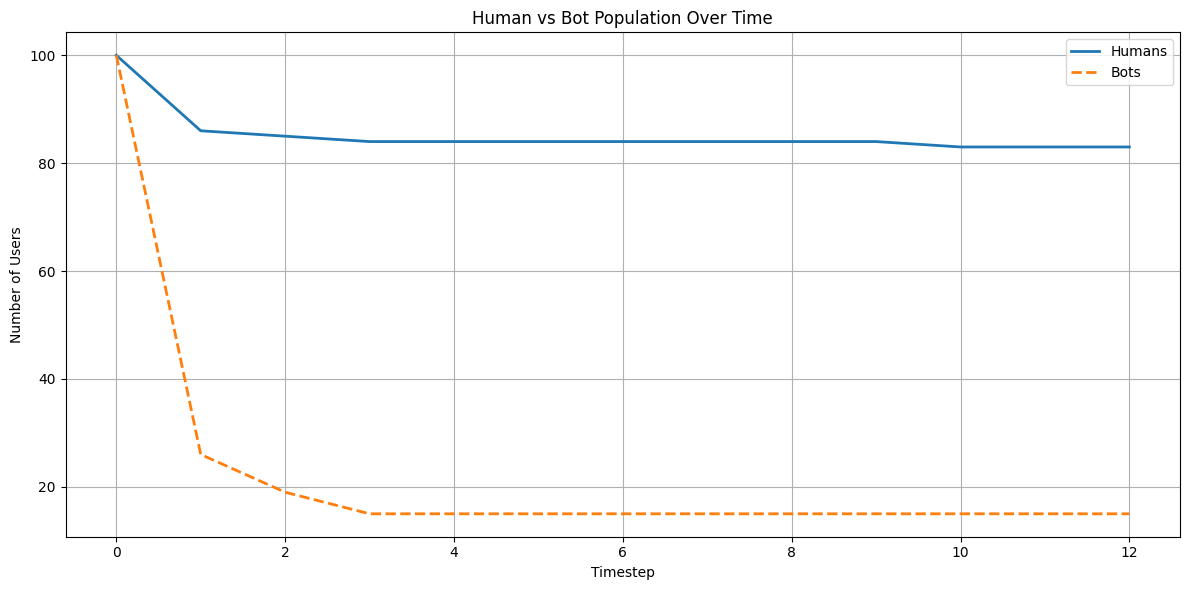

In [13]:
import matplotlib.pyplot as plt


plt.figure(figsize=(12, 6))

plt.plot(timestep_counts, human_counts,
         label="Humans",
         linestyle="-",
         linewidth=2)

plt.plot(timestep_counts, bot_counts,
         label="Bots",
         linestyle="--",
         linewidth=2)

plt.xlabel("Timestep")
plt.ylabel("Number of Users")
plt.title("Human vs Bot Population Over Time")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

--- Starting Offline Training Simulator ---
Loading raw session data from data...
Loaded 32 human sessions and 41 bot sessions.
Creating population: 85 humans, 1000 bots
Final remaining humans: 52
Final remaining bots: 87
All users finished.
Net reward: -181717.0
Normalized reward: -167.48
Confusion Matrix: {'human': {'predicted': {'human': 776, 'bot': 83}}, 'bot': {'predicted': {'human': 1296, 'bot': 966}}}


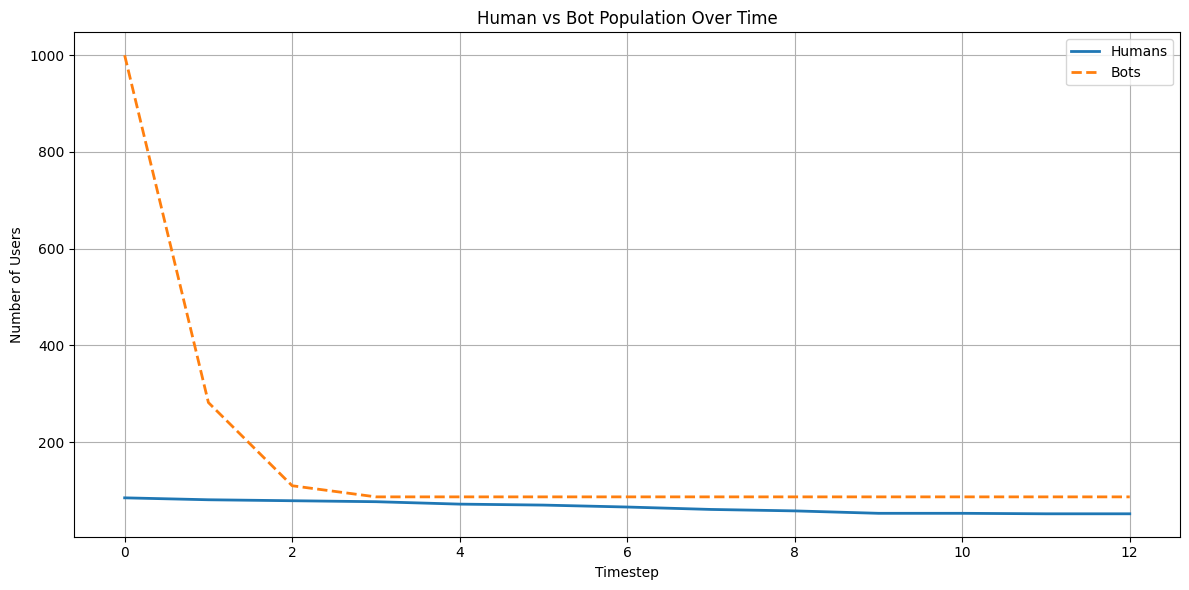

In [29]:
# Track population over time
human_counts = []
bot_counts = []
timestep_counts = []
current_timestep = 0

# This dict holds the (s, a, r, done) tuple from step t-1, waiting for s' at step t
pending_experiences = {}
episode_reward = 0

print("--- Starting Offline Training Simulator ---")
base_human_sessions, base_bot_sessions = load_session_data(DATA_DIR)

update_human_bot_population(human_count=85, bot_count=1000)

# 1. Create the population for this episode
print(f"Creating population: {TARGET_HUMAN_COUNT} humans, {TARGET_BOT_COUNT} bots")
active_users = []
for _ in range(TARGET_HUMAN_COUNT):
    active_users.append(SimulatedUser(random.choice(base_human_sessions), is_bot=False))
for _ in range(TARGET_BOT_COUNT):
    active_users.append(SimulatedUser(random.choice(base_bot_sessions), is_bot=True))
    
random.shuffle(active_users)

human_count = TARGET_HUMAN_COUNT
bot_count = TARGET_BOT_COUNT

while active_users:
    # ---- Population tracking per timestep ----
    human_count = sum(1 for u in active_users if not u.is_bot)
    bot_count = sum(1 for u in active_users if u.is_bot)
    
    human_counts.append(human_count)
    bot_counts.append(bot_count)
    timestep_counts.append(current_timestep)
    current_timestep += 1
    
    server_total_users = len(active_users)
    server_req_rate_per_min = server_total_users * 7   # (random.randint(5, 15))

    next_active_users = []
    new_pending_experiences = {}

    for user in active_users:
        # 1. Get user's data and calculate current state s_t
        mouse_data = user.get_step_data()
        humanity_score = get_humanity_score(mouse_data)
        
        # if user.is_bot and humanity_score is not None:
        #     humanity_score = humanity_score ** 4
            # print(humanity_score)

        user.update_stats(humanity_score)

        if humanity_score is None:
            humanity_score = user.average_humanity_score

        conf["bot" if user.is_bot else "human"]["predicted"]["bot" if humanity_score >= .5 else "human"] += 1
        # print(user.is_bot, humanity_score)

        s_t = [
            humanity_score,
            user.average_humanity_score,
            user.captchas_solved,
            user.last_captcha_solved,   # client_req_rate_per_min, avg_h_score
            # server_req_rate_per_min,
            server_total_users
        ]

        # 2. Finalize the experience from step t-1
        if user.client_id in pending_experiences:
            prev_s, prev_a, prev_r, prev_done = pending_experiences[user.client_id]
            s_prime = s_t  # The current state is the "next_state" for the previous action

            # Store the *completed* transition from t-1
            # offline_rl_agent.remember(prev_s, prev_a, prev_r, s_prime, prev_done, user.is_bot)
            episode_reward += prev_r

        # 3. Check if user's session ended *naturally* (ran out of data)
        if user.done:
            continue  # User is done, no new action to take

        # 4. User is still active, take a new action (a_t)
        # a_t = offline_rl_agent.select_action(s_t)
        
        a_t = 10 if humanity_score > 0.5 else 0   
        # a_t = int(humanity_score * 10)

        # 5. Calculate reward (r_t) and if the action *caused* the session to end (done_t)
        r_t, done_t = calculate_reward(user, a_t)

        # print(f"{'Bottt' if user.is_bot else 'Human'} -> action: {a_t}, reward {r_t}, done: {done_t}, score: {humanity_score}")

        # 6. Store this new experience
        if done_t:
            # This is a terminal state (e.g., bot was killed).
            # We have the full experience now. Store it immediately.
            s_prime = s_t  # The 'next_state' is arbitrary, as 'done=True' nullifies it.
            # offline_rl_agent.remember(s_t, a_t, r_t, s_prime, True, user.is_bot)
            episode_reward += r_t
            
            # if user.is_bot:
            #     bot_count -= 1
            
        else:
            # This is a non-terminal state.
            # Store it as pending, waiting for s' from the next step.
            new_pending_experiences[user.client_id] = (s_t, a_t, r_t, done_t)
            user.last_captcha_solved = a_t
            next_active_users.append(user)  # User continues

    if not next_active_users:
        print(f"Final remaining humans: {sum(1 for u in active_users if not u.is_bot)}")
        print(f"Final remaining bots: {sum(1 for u in active_users if u.is_bot)}")

    # --- End of Step ---
    active_users = next_active_users
    pending_experiences = new_pending_experiences

    if not active_users:
        print(f"All users finished.")
        
print(f"Net reward: {episode_reward}")
print(f"Normalized reward: {episode_reward / (TARGET_BOT_COUNT + TARGET_HUMAN_COUNT):0.2f}")
print(f"Confusion Matrix: {conf}")


plt.figure(figsize=(12, 6))

plt.plot(timestep_counts, human_counts,
         label="Humans",
         linestyle="-",
         linewidth=2)

plt.plot(timestep_counts, bot_counts,
         label="Bots",
         linestyle="--",
         linewidth=2)

plt.xlabel("Timestep")
plt.ylabel("Number of Users")
plt.title("Human vs Bot Population Over Time")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
import json

bot_counts_lst = [0, 20, 100, 200, 500, 1000]
h_count = 100

dct = dict()

for b_count in bot_counts_lst:
    update_human_bot_population(human_count=h_count, bot_count=b_count)

    # Track population over time
    human_counts = []
    bot_counts = []
    timestep_counts = []
    current_timestep = 0

    # This dict holds the (s, a, r, done) tuple from step t-1, waiting for s' at step t
    pending_experiences = {}
    episode_reward = 0
    global_step_counter = 0
    episode_h_step_counter = 0
    episode_b_step_counter = 0
    episode_human_reward = 0
    episode_bot_reward = 0

    print("--- Starting Offline Training Simulator ---")
    base_human_sessions, base_bot_sessions = load_session_data(DATA_DIR)

    # 1. Create the population for this episode
    print(f"Creating population: {TARGET_HUMAN_COUNT} humans, {TARGET_BOT_COUNT} bots")
    active_users = []
    for _ in range(TARGET_HUMAN_COUNT):
        active_users.append(SimulatedUser(random.choice(base_human_sessions), is_bot=False))
    for _ in range(TARGET_BOT_COUNT):
        active_users.append(SimulatedUser(random.choice(base_bot_sessions), is_bot=True))
        
    random.shuffle(active_users)

    human_count = TARGET_HUMAN_COUNT
    bot_count = TARGET_BOT_COUNT

    while active_users:
        # ---- Population tracking per timestep ----
        human_count = sum(1 for u in active_users if not u.is_bot)
        bot_count = sum(1 for u in active_users if u.is_bot)
        
        human_counts.append(human_count)
        bot_counts.append(bot_count)
        timestep_counts.append(current_timestep)
        current_timestep += 1
        
        server_total_users = len(active_users)
        server_req_rate_per_min = server_total_users * 7   # (random.randint(5, 15))

        next_active_users = []
        new_pending_experiences = {}

        for user in active_users:
            # 1. Get user's data and calculate current state s_t
            mouse_data = user.get_step_data()
            humanity_score = get_humanity_score(mouse_data)
            
            # if user.is_bot and humanity_score is not None:
            #     humanity_score = humanity_score ** 4
                # print(humanity_score)

            user.update_stats(humanity_score)

            if humanity_score is None:
                humanity_score = user.average_humanity_score

            conf["bot" if user.is_bot else "human"]["predicted"]["bot" if humanity_score >= .5 else "human"] += 1
            # print(user.is_bot, humanity_score)

            s_t = [
                humanity_score,
                user.average_humanity_score,
                user.captchas_solved,
                user.last_captcha_solved,   # client_req_rate_per_min, avg_h_score
                # server_req_rate_per_min,
                server_total_users
            ]

            # 2. Finalize the experience from step t-1
            if user.client_id in pending_experiences:
                prev_s, prev_a, prev_r, prev_done = pending_experiences[user.client_id]
                s_prime = s_t  # The current state is the "next_state" for the previous action

                # Store the *completed* transition from t-1
                # offline_rl_agent.remember(prev_s, prev_a, prev_r, s_prime, prev_done, user.is_bot)
                episode_reward += prev_r

            # 3. Check if user's session ended *naturally* (ran out of data)
            if user.done:
                continue  # User is done, no new action to take

            # 4. User is still active, take a new action (a_t)
            # a_t = offline_rl_agent.select_action(s_t)
            
            a_t = 10 if humanity_score > 0.5 else 0   
            # a_t = int(humanity_score * 10)

            # 5. Calculate reward (r_t) and if the action *caused* the session to end (done_t)
            r_t, done_t = calculate_reward(user, a_t)

            if user.is_bot:
                episode_bot_reward += r_t
                episode_b_step_counter += 1
            else:
                episode_human_reward += r_t
                episode_h_step_counter += 1

            global_step_counter += 1


            # print(f"{'Bottt' if user.is_bot else 'Human'} -> action: {a_t}, reward {r_t}, done: {done_t}, score: {humanity_score}")

            # 6. Store this new experience
            if done_t:
                # This is a terminal state (e.g., bot was killed).
                # We have the full experience now. Store it immediately.
                s_prime = s_t  # The 'next_state' is arbitrary, as 'done=True' nullifies it.
                # offline_rl_agent.remember(s_t, a_t, r_t, s_prime, True, user.is_bot)
                episode_reward += r_t
                
                # if user.is_bot:
                #     bot_count -= 1
                
            else:
                # This is a non-terminal state.
                # Store it as pending, waiting for s' from the next step.
                new_pending_experiences[user.client_id] = (s_t, a_t, r_t, done_t)
                user.last_captcha_solved = a_t
                next_active_users.append(user)  # User continues

        if not next_active_users:
            print(f"Final remaining humans: {sum(1 for u in active_users if not u.is_bot)}")
            print(f"Final remaining bots: {sum(1 for u in active_users if u.is_bot)}")

        # --- End of Step ---
        active_users = next_active_users
        pending_experiences = new_pending_experiences

        if not active_users:
            print(f"All users finished.")

    # Metrics logging...
    avg_rew = episode_reward / (episode_h_step_counter + episode_b_step_counter)   # (TARGET_HUMAN_COUNT + TARGET_BOT_COUNT)
    avg_human_rew = episode_human_reward / episode_h_step_counter
    avg_bot_rew = episode_bot_reward / episode_b_step_counter if episode_b_step_counter else 0
    print(f"Total Reward: {episode_reward:.2f} | Avg: {avg_rew:.2f} | Avg Human: {avg_human_rew:.2f} | Avg Bot: {avg_bot_rew:.2f}")
        
    avg_session_rew = episode_reward / (TARGET_HUMAN_COUNT + TARGET_BOT_COUNT)
    avg_h_session_rew = episode_human_reward / (TARGET_HUMAN_COUNT)
    avg_b_session_rew = episode_bot_reward / TARGET_BOT_COUNT if TARGET_BOT_COUNT else 0
    print(f"Average Session Rewards::: Mean: {avg_session_rew:.2f} | Human: {avg_h_session_rew:.2f} | Bot: {avg_b_session_rew:.2f}")
            
    print(f"Net reward: {episode_reward}")
    print(f"Normalized reward: {episode_reward / (TARGET_BOT_COUNT + TARGET_HUMAN_COUNT):0.2f}")
    print("Confusion Matrix:\n", conf)
    print("\n\n")

    dct[b_count] = {
        "timesteps": timestep_counts,
        "human_counts": human_counts,
        "bot_counts": bot_counts
    }

with open("eval_static_threshold.json", "w") as f:
    json.dump(dct, f)

--- Starting Offline Training Simulator ---
Loading raw session data from data...
Loaded 32 human sessions and 41 bot sessions.
Creating population: 100 humans, 0 bots
Final remaining humans: 51
Final remaining bots: 0
All users finished.
Total Reward: -8001.00 | Avg: -9.22 | Avg Human: -9.22 | Avg Bot: 0.00
Average Session Rewards::: Mean: -80.01 | Human: -80.01 | Bot: 0.00
Net reward: -8001.0
Normalized reward: -80.01
Confusion Matrix:
 {'human': {'predicted': {'human': 819, 'bot': 100}}, 'bot': {'predicted': {'human': 0, 'bot': 0}}}



--- Starting Offline Training Simulator ---
Loading raw session data from data...
Loaded 32 human sessions and 41 bot sessions.
Creating population: 100 humans, 20 bots
Final remaining humans: 58
Final remaining bots: 1
All users finished.
Total Reward: -60.50 | Avg: -0.06 | Avg Human: 1.90 | Avg Bot: -54.62
Average Session Rewards::: Mean: -0.50 | Human: 17.42 | Bot: -90.12
Net reward: -60.5
Normalized reward: -0.50
Confusion Matrix:
 {'human': {'pre

In [ ]:
import json

bot_counts_lst = [0, 20, 100, 200, 500, 1000]
h_count = 100

dct = dict()

for b_count in bot_counts_lst:
    update_human_bot_population(human_count=h_count, bot_count=b_count)

    # Track population over time
    human_counts = []
    bot_counts = []
    timestep_counts = []
    current_timestep = 0

    # This dict holds the (s, a, r, done) tuple from step t-1, waiting for s' at step t
    pending_experiences = {}
    episode_reward = 0
    global_step_counter = 0
    episode_h_step_counter = 0
    episode_b_step_counter = 0
    episode_human_reward = 0
    episode_bot_reward = 0

    print("--- Starting Offline Training Simulator ---")
    base_human_sessions, base_bot_sessions = load_session_data(DATA_DIR)

    # 1. Create the population for this episode
    print(f"Creating population: {TARGET_HUMAN_COUNT} humans, {TARGET_BOT_COUNT} bots")
    active_users = []
    for _ in range(TARGET_HUMAN_COUNT):
        active_users.append(SimulatedUser(random.choice(base_human_sessions), is_bot=False))
    for _ in range(TARGET_BOT_COUNT):
        active_users.append(SimulatedUser(random.choice(base_bot_sessions), is_bot=True))
        
    random.shuffle(active_users)

    human_count = TARGET_HUMAN_COUNT
    bot_count = TARGET_BOT_COUNT

    while active_users:
        # ---- Population tracking per timestep ----
        human_count = sum(1 for u in active_users if not u.is_bot)
        bot_count = sum(1 for u in active_users if u.is_bot)
        
        human_counts.append(human_count)
        bot_counts.append(bot_count)
        timestep_counts.append(current_timestep)
        current_timestep += 1
        
        server_total_users = len(active_users)
        server_req_rate_per_min = server_total_users * 7   # (random.randint(5, 15))

        next_active_users = []
        new_pending_experiences = {}

        for user in active_users:
            # 1. Get user's data and calculate current state s_t
            mouse_data = user.get_step_data()
            humanity_score = get_humanity_score(mouse_data)
            
            # if user.is_bot and humanity_score is not None:
            #     humanity_score = humanity_score ** 4
                # print(humanity_score)

            user.update_stats(humanity_score)

            if humanity_score is None:
                humanity_score = user.average_humanity_score

            conf["bot" if user.is_bot else "human"]["predicted"]["bot" if humanity_score >= .5 else "human"] += 1
            # print(user.is_bot, humanity_score)

            s_t = [
                humanity_score,
                user.average_humanity_score,
                user.captchas_solved,
                user.last_captcha_solved,   # client_req_rate_per_min, avg_h_score
                # server_req_rate_per_min,
                server_total_users
            ]

            # 2. Finalize the experience from step t-1
            if user.client_id in pending_experiences:
                prev_s, prev_a, prev_r, prev_done = pending_experiences[user.client_id]
                s_prime = s_t  # The current state is the "next_state" for the previous action

                # Store the *completed* transition from t-1
                # offline_rl_agent.remember(prev_s, prev_a, prev_r, s_prime, prev_done, user.is_bot)
                episode_reward += prev_r

            # 3. Check if user's session ended *naturally* (ran out of data)
            if user.done:
                continue  # User is done, no new action to take

            # 4. User is still active, take a new action (a_t)
            # a_t = offline_rl_agent.select_action(s_t)
            
            # a_t = 10 if humanity_score > 0.5 else 0   
            a_t = int(humanity_score * 10)

            # 5. Calculate reward (r_t) and if the action *caused* the session to end (done_t)
            r_t, done_t = calculate_reward(user, a_t)

            if user.is_bot:
                episode_bot_reward += r_t
                episode_b_step_counter += 1
            else:
                episode_human_reward += r_t
                episode_h_step_counter += 1

            global_step_counter += 1

            # print(f"{'Bottt' if user.is_bot else 'Human'} -> action: {a_t}, reward {r_t}, done: {done_t}, score: {humanity_score}")

            # 6. Store this new experience
            if done_t:
                # This is a terminal state (e.g., bot was killed).
                # We have the full experience now. Store it immediately.
                s_prime = s_t  # The 'next_state' is arbitrary, as 'done=True' nullifies it.
                # offline_rl_agent.remember(s_t, a_t, r_t, s_prime, True, user.is_bot)
                episode_reward += r_t
                
                # if user.is_bot:
                #     bot_count -= 1
                
            else:
                # This is a non-terminal state.
                # Store it as pending, waiting for s' from the next step.
                new_pending_experiences[user.client_id] = (s_t, a_t, r_t, done_t)
                user.last_captcha_solved = a_t
                next_active_users.append(user)  # User continues

        if not next_active_users:
            print(f"Final remaining humans: {sum(1 for u in active_users if not u.is_bot)}")
            print(f"Final remaining bots: {sum(1 for u in active_users if u.is_bot)}")

        # --- End of Step ---
        active_users = next_active_users
        pending_experiences = new_pending_experiences

        if not active_users:
            print(f"All users finished.")

    # Metrics logging...
    avg_rew = episode_reward / (episode_h_step_counter + episode_b_step_counter)   # (TARGET_HUMAN_COUNT + TARGET_BOT_COUNT)
    avg_human_rew = episode_human_reward / episode_h_step_counter
    avg_bot_rew = episode_bot_reward / episode_b_step_counter if episode_b_step_counter else 0
    print(f"Total Reward: {episode_reward:.2f} | Avg: {avg_rew:.2f} | Avg Human: {avg_human_rew:.2f} | Avg Bot: {avg_bot_rew:.2f}")
        
    avg_session_rew = episode_reward / (TARGET_HUMAN_COUNT + TARGET_BOT_COUNT)
    avg_h_session_rew = episode_human_reward / (TARGET_HUMAN_COUNT)
    avg_b_session_rew = episode_bot_reward / TARGET_BOT_COUNT if TARGET_BOT_COUNT else 0
    print(f"Average Session Rewards::: Mean: {avg_session_rew:.2f} | Human: {avg_h_session_rew:.2f} | Bot: {avg_b_session_rew:.2f}")
            
    print(f"Net reward: {episode_reward}")
    print(f"Normalized reward: {episode_reward / (TARGET_BOT_COUNT + TARGET_HUMAN_COUNT):0.2f}")
    print("Confusion Matrix:\n", conf)
    print("\n\n")

    dct[b_count] = {
        "timesteps": timestep_counts,
        "human_counts": human_counts,
        "bot_counts": bot_counts
    }

with open("eval_static_tiers.json", "w") as f:
    json.dump(dct, f)

--- Starting Offline Training Simulator ---
Loading raw session data from data...
Loaded 32 human sessions and 41 bot sessions.
Creating population: 100 humans, 0 bots
Final remaining humans: 69
Final remaining bots: 0
All users finished.
Total Reward: 21776.00 | Avg: 20.88 | Avg Human: 20.88 | Avg Bot: 0.00
Average Session Rewards::: Mean: 217.76 | Human: 217.76 | Bot: 0.00
Net reward: 21776.0
Normalized reward: 217.76
Confusion Matrix:
 {'human': {'predicted': {'human': 954, 'bot': 158}}, 'bot': {'predicted': {'human': 0, 'bot': 0}}}



--- Starting Offline Training Simulator ---
Loading raw session data from data...
Loaded 32 human sessions and 41 bot sessions.
Creating population: 100 humans, 20 bots
Final remaining humans: 65
Final remaining bots: 1
All users finished.
Total Reward: 17422.00 | Avg: 16.44 | Avg Human: 19.31 | Avg Bot: -60.79
Average Session Rewards::: Mean: 145.18 | Human: 197.32 | Bot: -115.50
Net reward: 17422.0
Normalized reward: 145.18
Confusion Matrix:
 {'huma

--- Starting Offline Training Simulator ---
Loading raw session data from data...
Loaded 32 human sessions and 41 bot sessions.
Creating population: 85 humans, 1000 bots
Final remaining humans: 56
Final remaining bots: 163
All users finished.
Net reward: -301096.0
Normalized reward: -277.51
Confusion Matrix: {'human': {'predicted': {'human': 754, 'bot': 147}}, 'bot': {'predicted': {'human': 1339, 'bot': 1793}}}


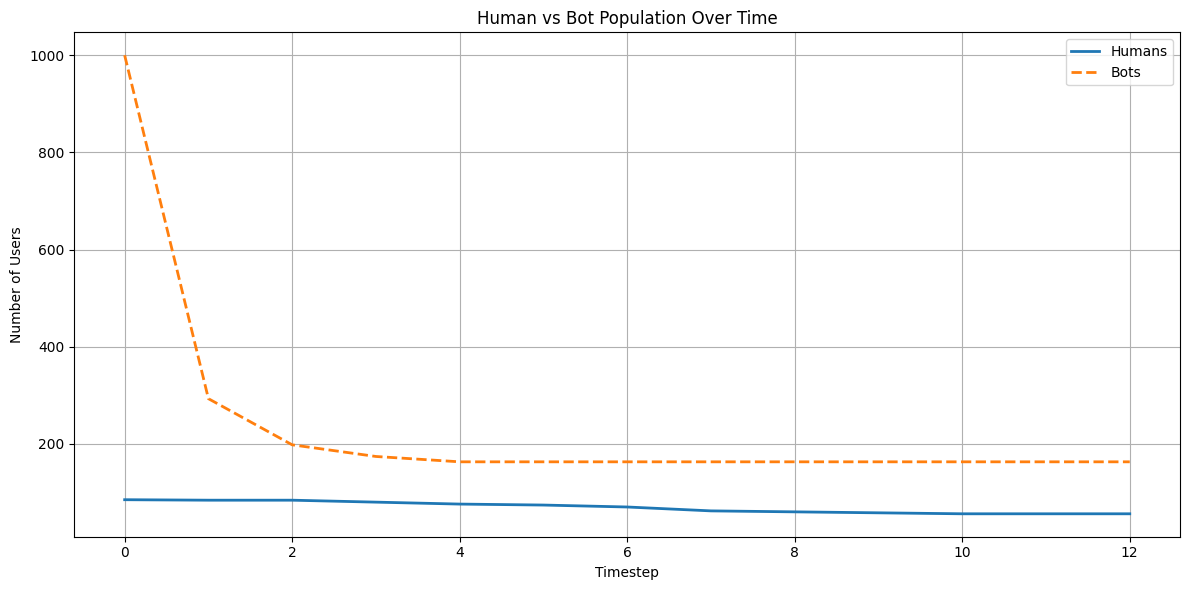

In [30]:
# Track population over time
human_counts = []
bot_counts = []
timestep_counts = []
current_timestep = 0

# This dict holds the (s, a, r, done) tuple from step t-1, waiting for s' at step t
pending_experiences = {}
episode_reward = 0

print("--- Starting Offline Training Simulator ---")
base_human_sessions, base_bot_sessions = load_session_data(DATA_DIR)

update_human_bot_population(human_count=85, bot_count=1000)

# 1. Create the population for this episode
print(f"Creating population: {TARGET_HUMAN_COUNT} humans, {TARGET_BOT_COUNT} bots")
active_users = []
for _ in range(TARGET_HUMAN_COUNT):
    active_users.append(SimulatedUser(random.choice(base_human_sessions), is_bot=False))
for _ in range(TARGET_BOT_COUNT):
    active_users.append(SimulatedUser(random.choice(base_bot_sessions), is_bot=True))
    
random.shuffle(active_users)

human_count = TARGET_HUMAN_COUNT
bot_count = TARGET_BOT_COUNT

while active_users:
    # ---- Population tracking per timestep ----
    human_count = sum(1 for u in active_users if not u.is_bot)
    bot_count = sum(1 for u in active_users if u.is_bot)
    
    human_counts.append(human_count)
    bot_counts.append(bot_count)
    timestep_counts.append(current_timestep)
    current_timestep += 1
    
    server_total_users = len(active_users)
    server_req_rate_per_min = server_total_users * 7   # (random.randint(5, 15))

    next_active_users = []
    new_pending_experiences = {}

    for user in active_users:
        # 1. Get user's data and calculate current state s_t
        mouse_data = user.get_step_data()
        humanity_score = get_humanity_score(mouse_data)
        
        # if user.is_bot and humanity_score is not None:
        #     humanity_score = humanity_score ** 4
            # print(humanity_score)

        user.update_stats(humanity_score)

        if humanity_score is None:
            humanity_score = user.average_humanity_score

        conf["bot" if user.is_bot else "human"]["predicted"]["bot" if humanity_score >= .5 else "human"] += 1
        # print(user.is_bot, humanity_score)

        s_t = [
            humanity_score,
            user.average_humanity_score,
            user.captchas_solved,
            user.last_captcha_solved,   # client_req_rate_per_min, avg_h_score
            # server_req_rate_per_min,
            server_total_users
        ]

        # 2. Finalize the experience from step t-1
        if user.client_id in pending_experiences:
            prev_s, prev_a, prev_r, prev_done = pending_experiences[user.client_id]
            s_prime = s_t  # The current state is the "next_state" for the previous action

            # Store the *completed* transition from t-1
            # offline_rl_agent.remember(prev_s, prev_a, prev_r, s_prime, prev_done, user.is_bot)
            episode_reward += prev_r

        # 3. Check if user's session ended *naturally* (ran out of data)
        if user.done:
            continue  # User is done, no new action to take

        # 4. User is still active, take a new action (a_t)
        # a_t = offline_rl_agent.select_action(s_t)
        
        # a_t = 10 if humanity_score > 0.5 else 0   
        a_t = int(humanity_score * 10)

        # 5. Calculate reward (r_t) and if the action *caused* the session to end (done_t)
        r_t, done_t = calculate_reward(user, a_t)

        # print(f"{'Bottt' if user.is_bot else 'Human'} -> action: {a_t}, reward {r_t}, done: {done_t}, score: {humanity_score}")

        # 6. Store this new experience
        if done_t:
            # This is a terminal state (e.g., bot was killed).
            # We have the full experience now. Store it immediately.
            s_prime = s_t  # The 'next_state' is arbitrary, as 'done=True' nullifies it.
            # offline_rl_agent.remember(s_t, a_t, r_t, s_prime, True, user.is_bot)
            episode_reward += r_t
            
            # if user.is_bot:
            #     bot_count -= 1
            
        else:
            # This is a non-terminal state.
            # Store it as pending, waiting for s' from the next step.
            new_pending_experiences[user.client_id] = (s_t, a_t, r_t, done_t)
            user.last_captcha_solved = a_t
            next_active_users.append(user)  # User continues

    if not next_active_users:
        print(f"Final remaining humans: {sum(1 for u in active_users if not u.is_bot)}")
        print(f"Final remaining bots: {sum(1 for u in active_users if u.is_bot)}")

    # --- End of Step ---
    active_users = next_active_users
    pending_experiences = new_pending_experiences

    if not active_users:
        print(f"All users finished.")
        
print(f"Net reward: {episode_reward}")
print(f"Normalized reward: {episode_reward / (TARGET_BOT_COUNT + TARGET_HUMAN_COUNT):0.2f}")
print(f"Confusion Matrix: {conf}")


plt.figure(figsize=(12, 6))

plt.plot(timestep_counts, human_counts,
         label="Humans",
         linestyle="-",
         linewidth=2)

plt.plot(timestep_counts, bot_counts,
         label="Bots",
         linestyle="--",
         linewidth=2)

plt.xlabel("Timestep")
plt.ylabel("Number of Users")
plt.title("Human vs Bot Population Over Time")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()